# CNN spatial head: classificazione di feature reali e sintetiche

## Abstract

Il notebook addestra una CNN compatta per distinguere feature map di immagini real, label 0, e fake, label 1. Apre i tensori originali in memory mapping, recupera un solo campione alla volta tramite l'indice condiviso e applica una normalizzazione per canale ottenuta esclusivamente dal training. Usa PyTorch, GroupNorm, blocchi depthwise-separable, attenzione ai canali, AMP su CUDA ed early stopping sulla balanced accuracy di validation. Salva checkpoint, modello TorchScript, predizioni, metriche e figure riutilizzabili dall'ensemble.

## Schema della pipeline completa

1. Setup portabile: rileva locale o Colab, monta Drive solo in Colab e usa una cache della VM per i due grandi file.
2. Contratti condivisi: convalida mapping delle classi, sample_index.csv, split e hash.
3. Input spaziale: accede con memory mapping a features_0.npy e features_1.npy, senza concatenarli in RAM.
4. Preprocessing: normalizza ogni canale con statistiche del training e epsilon 1e-6; non esegue augmentation.
5. Modello: Conv 1x1, tre blocchi residuali depthwise-separable, attenzione ai canali, pooling medio e massimo, classificatore binario.
6. Selezione: AdamW, gradient clipping, AMP condizionale ed early stopping sulla balanced accuracy validation.
7. Valutazione: sceglie la soglia sul validation, valuta train/validation/test e salva gli artefatti per il confronto e l'ensemble.

## Struttura della CNN

```text
Input: feature map normalizzata [1280, 16, 16]
                    |
                    v
Stem
  Conv2d 1x1: 1280 -> 128 canali
  GroupNorm + GELU
                    |
                    v
3x ResidualDepthwiseBlock
  +--------------------------------------------------+
  | Depthwise Conv2d 3x3, groups=128                |
  | GroupNorm + GELU                                |
  | Pointwise Conv2d 1x1                            |
  | GroupNorm                                       |
  | Residual add: input + output                    |
  | GELU                                            |
  +--------------------------------------------------+
                    |
                    v
Channel attention
  AdaptiveAvgPool2d(1) -> Conv 128 -> 16 -> GELU
  -> Conv 16 -> 128 -> Sigmoid
  -> moltiplicazione elemento per elemento
                    |
                    v
Global pooling parallelo
  AdaptiveAvgPool2d(1)  ----> 128 valori
  AdaptiveMaxPool2d(1)  ----> 128 valori
                    |
                    v
Concatenazione: 256 valori
                    |
                    v
Classification head
  Linear 256 -> 64 -> GELU -> Dropout(0.30)
  -> Linear 64 -> 1 logit
                    |
                    v
Output: logit binario
  sigmoid durante l'inferenza -> probabilita' fake
```

**Lettura dello schema.** Lo stem riduce i 1280 canali a 128 mantenendo la griglia spaziale `16 x 16`. I blocchi residuali estraggono pattern locali con poche operazioni grazie alla separazione tra convoluzione depthwise e pointwise; il collegamento residuo facilita il flusso del gradiente. L'attenzione ripesa i canali in base al contenuto globale della feature map. Il pooling medio cattura l'attivazione tipica, mentre quello massimo conserva le risposte piu' forti: la loro concatenazione produce il vettore da 256 elementi usato dal classificatore finale.

Il modello restituisce un singolo logit. La funzione sigmoide viene applicata nell'inferenza per ottenere la probabilita' della classe fake; la soglia decisionale viene determinata separatamente sulla validation.

## 1. Setup portabile dei percorsi

Questa cella rileva l'ambiente. In Colab monta Drive, verifica i file e li copia nella VM per letture rapide; in locale ricava la root dal notebook. Tutte le directory successive derivano esclusivamente dalle variabili configurate qui.

In [ ]:
from pathlib import Path
import importlib.util
import shutil

try:
    IS_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IS_COLAB = False

EXPECTED_FILES = {"features_0.npy": 2_167_931_008, "features_1.npy": 3_123_445_888}

if IS_COLAB:
    from google.colab import drive
    DRIVE_MOUNT = Path("/content/drive")
    if not (DRIVE_MOUNT / "MyDrive").exists():
        drive.mount(str(DRIVE_MOUNT), force_remount=False)
    PROJECT_ROOT = DRIVE_MOUNT / "MyDrive" / "Magistrale" / "Advanced_ML" / "progetto_aml"
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / "dataset"
    if not PERSISTENT_DATASET_DIR.is_dir():
        raise FileNotFoundError(f"Dataset directory non trovata su Drive: {PERSISTENT_DATASET_DIR}")
    RUNTIME_PROJECT_ROOT = Path("/content/progetto_aml")
    RUNTIME_DATASET_DIR = RUNTIME_PROJECT_ROOT / "dataset"
    RUNTIME_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    for filename, expected_size in EXPECTED_FILES.items():
        source, destination = PERSISTENT_DATASET_DIR / filename, RUNTIME_DATASET_DIR / filename
        if not source.is_file() or source.stat().st_size != expected_size:
            raise RuntimeError(f"File originale assente o di dimensione errata: {source}")
        if not destination.is_file() or destination.stat().st_size != expected_size:
            print(f"Copio {filename} da Drive alla VM Colab...")
            shutil.copy2(source, destination)
        if destination.stat().st_size != expected_size:
            raise RuntimeError(f"Copia incompleta: {destination}")
    DATASET_DIR = RUNTIME_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / "artifacts", PROJECT_ROOT / "results"
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "dataset").is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    RUNTIME_PROJECT_ROOT = PROJECT_ROOT
    PERSISTENT_DATASET_DIR = DATASET_DIR = PROCESSED_DATASET_DIR = PROJECT_ROOT / "dataset"
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / "artifacts", PROJECT_ROOT / "results"

if not PERSISTENT_DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Dataset directory non trovata: {PERSISTENT_DATASET_DIR}")
for directory in (PROCESSED_DATASET_DIR, ARTIFACTS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print("Ambiente:", "Google Colab" if IS_COLAB else "Locale")
print("Dataset:", DATASET_DIR)
print("Risultati:", RESULTS_DIR)

## 2. Dipendenze, semi e configurazione

Questa cella installa soltanto dipendenze assenti, registra le versioni, imposta la riproducibilità e sceglie CUDA con fallback CPU. I parametri iniziali sono conservativi per una GPU locale con 6 GB di VRAM.

In [ ]:
import hashlib
import importlib
import json
import platform
import random
import subprocess
import sys
import time
from contextlib import nullcontext
from datetime import datetime, timezone

required = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "sklearn": "scikit-learn", "torch": "torch", "tqdm": "tqdm"}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED, BATCH_SIZE, NUM_WORKERS = 42, 8, 0
MAX_EPOCHS, PATIENCE, LEARNING_RATE, WEIGHT_DECAY = 80, 12, 3e-4, 1e-3
GRADIENT_CLIP_NORM, DROPOUT, EPSILON = 1.0, 0.30, 1e-6
MODEL_NAME = "cnn_spatial_head"
RUN_ID = f"seed{SEED}_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
VERSIONS = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__, "torch": torch.__version__, "cuda": torch.version.cuda, "device": str(DEVICE)}
print(json.dumps(VERSIONS, indent=2))
print("Run ID:", RUN_ID)

## 3. Mapping, indice e split condiviso

Questa cella dichiara in modo esplicito le classi, valida l'indice persistente e carica o crea lo split stratificato solo se assente. Controlla copertura, disgiunzione, range, distribuzione delle classi e hash stabile dello split.

In [ ]:
CLASS_MAPPING = {"features_0.npy": {"label": 0, "name": "real"}, "features_1.npy": {"label": 1, "name": "fake"}}
POSITIVE_LABEL, POSITIVE_CLASS = 1, "fake"
N_REAL, N_FAKE, N_SAMPLES = 1654, 2383, 4037
SAMPLE_INDEX_PATH, SPLIT_PATH = PROCESSED_DATASET_DIR / "sample_index.csv", ARTIFACTS_DIR / "splits_seed42.npz"
if not SAMPLE_INDEX_PATH.is_file():
    raise FileNotFoundError(f"Indice campioni mancante: {SAMPLE_INDEX_PATH}. Eseguire prima dataset_exploration.ipynb.")
sample_index = pd.read_csv(SAMPLE_INDEX_PATH)
required_columns = {"sample_id", "source_file", "source_index", "label"}
if len(sample_index) != N_SAMPLES or not required_columns.issubset(sample_index.columns) or not sample_index["sample_id"].is_unique:
    raise ValueError("sample_index.csv non rispetta il contratto comune")
if not set(sample_index["source_file"]).issubset(CLASS_MAPPING):
    raise ValueError("source_file contiene valori non previsti")
expected_labels = sample_index["source_file"].map(lambda name: CLASS_MAPPING[name]["label"]).to_numpy()
labels = sample_index["label"].to_numpy(dtype=np.int64)
if not np.array_equal(labels, expected_labels):
    raise ValueError("Le label non rispettano il mapping esplicito")

if SPLIT_PATH.is_file():
    split_file = np.load(SPLIT_PATH, allow_pickle=False)
    train_indices, validation_indices, test_indices = (split_file[name].astype(np.int64) for name in ("train_indices", "validation_indices", "test_indices"))
else:
    indices = np.arange(N_SAMPLES, dtype=np.int64)
    train_indices, held_out = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
    validation_indices, test_indices = train_test_split(held_out, test_size=0.50, stratify=labels[held_out], random_state=SEED)
    np.savez_compressed(SPLIT_PATH, train_indices=np.sort(train_indices), validation_indices=np.sort(validation_indices), test_indices=np.sort(test_indices))
train_indices, validation_indices, test_indices = map(np.sort, (train_indices, validation_indices, test_indices))
all_indices = np.concatenate([train_indices, validation_indices, test_indices])
if len(np.unique(all_indices)) != N_SAMPLES or set(all_indices) != set(range(N_SAMPLES)):
    raise ValueError("Split non disgiunto, incompleto o fuori range")
hasher = hashlib.sha256()
for split_name, indices in (("train", train_indices), ("validation", validation_indices), ("test", test_indices)):
    hasher.update(split_name.encode("utf-8"))
    hasher.update(np.asarray(indices, dtype="<i8").tobytes())
SPLIT_HASH = hasher.hexdigest()
for name, indices in {"train": train_indices, "validation": validation_indices, "test": test_indices}.items():
    counts = np.bincount(labels[indices], minlength=2)
    print(f"{name}: {len(indices)} campioni, real={counts[0]}, fake={counts[1]}")
print("Split hash:", SPLIT_HASH)

def save_torch_checkpoint(checkpoint, filename, run_dir):
    final_path = run_dir / filename
    if IS_COLAB:
        temporary_path = RUNTIME_PROJECT_ROOT / filename
        torch.save(checkpoint, temporary_path)
        shutil.copy2(temporary_path, final_path)
        temporary_path.unlink()
    else:
        torch.save(checkpoint, final_path)
    if not final_path.is_file():
        raise RuntimeError(f"Checkpoint non salvato: {final_path}")
    return final_path

## 4. Apertura memory-mapped e statistiche spaziali

Questa cella apre i grandi tensori senza concatenarli, verifica shape e dtype e carica la normalizzazione per canale. Le statistiche devono corrispondere allo split condiviso ed essere state calcolate solamente sul training.

In [ ]:
features_real = np.load(DATASET_DIR / "features_0.npy", mmap_mode="r", allow_pickle=False)
features_fake = np.load(DATASET_DIR / "features_1.npy", mmap_mode="r", allow_pickle=False)
if features_real.shape != (N_REAL, 1280, 16, 16) or features_fake.shape != (N_FAKE, 1280, 16, 16):
    raise ValueError("Shape delle feature map non valida")
if features_real.dtype != np.float32 or features_fake.dtype != np.float32:
    raise TypeError("Le feature originali devono essere float32")

normalization_path = PROCESSED_DATASET_DIR / "spatial_channel_normalization.npz"
if not normalization_path.is_file():
    raise FileNotFoundError(f"Statistiche spaziali mancanti: {normalization_path}")
normalization = np.load(normalization_path, allow_pickle=False)
channel_mean = np.asarray(normalization["channel_mean"], dtype=np.float32)
channel_std = np.asarray(normalization["channel_std"], dtype=np.float32)
if channel_mean.shape != (1280,) or channel_std.shape != (1280,) or not np.isfinite(channel_mean).all() or not np.isfinite(channel_std).all() or np.any(channel_std <= 0):
    raise ValueError("Statistiche di normalizzazione non valide")
if not np.isclose(float(normalization["epsilon"]), EPSILON) or str(normalization["split_hash"]) != SPLIT_HASH:
    raise ValueError("Le statistiche di normalizzazione non appartengono al training dello split corrente")
print("Real:", features_real.shape, features_real.dtype)
print("Fake:", features_fake.shape, features_fake.dtype)
print("Campioni usati per le statistiche:", int(normalization["training_samples"]))

## 5. Dataset deterministico e CNN spatial head

Questa cella implementa il Dataset senza pipeline di augmentation: seleziona il file corretto con l'indice, copia soltanto il singolo campione in float32 e normalizza i 1280 canali. Definisce poi la CNN compatta con GroupNorm, blocchi residuali depthwise-separable e attenzione ai canali.

In [ ]:
class SpatialFeatureDataset(Dataset):
    def __init__(self, indices):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.source_files = sample_index["source_file"].to_numpy()
        self.source_indices = sample_index["source_index"].to_numpy(dtype=np.int64)
        self.targets = labels.astype(np.float32)
        self.mean = channel_mean.reshape(1280, 1, 1)
        self.std = np.maximum(channel_std.reshape(1280, 1, 1), np.float32(EPSILON))
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, position):
        global_index = int(self.indices[position])
        source = self.source_files[global_index]
        local_index = int(self.source_indices[global_index])
        if source == "features_0.npy":
            values = features_real[local_index]
        elif source == "features_1.npy":
            values = features_fake[local_index]
        else:
            raise ValueError(f"Source file non supportato: {source}")
        values = np.array(values, dtype=np.float32, copy=True)
        values -= self.mean
        values /= self.std
        return torch.from_numpy(values), torch.tensor(self.targets[global_index], dtype=torch.float32)

class ResidualDepthwiseBlock(nn.Module):
    def __init__(self, channels=128):
        super().__init__()
        self.depthwise = nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False)
        self.norm_a = nn.GroupNorm(8, channels)
        self.pointwise = nn.Conv2d(channels, channels, 1, bias=False)
        self.norm_b = nn.GroupNorm(8, channels)
        self.activation = nn.GELU()
    def forward(self, inputs):
        outputs = self.activation(self.norm_a(self.depthwise(inputs)))
        outputs = self.norm_b(self.pointwise(outputs))
        return self.activation(inputs + outputs)

class CNNSpatialHead(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(1280, 128, 1, bias=False), nn.GroupNorm(8, 128), nn.GELU())
        self.blocks = nn.Sequential(*[ResidualDepthwiseBlock() for _ in range(3)])
        self.attention = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(128, 16, 1), nn.GELU(), nn.Conv2d(16, 128, 1), nn.Sigmoid())
        self.avg_pool, self.max_pool = nn.AdaptiveAvgPool2d(1), nn.AdaptiveMaxPool2d(1)
        self.head = nn.Sequential(nn.Linear(256, 64), nn.GELU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, inputs):
        outputs = self.blocks(self.stem(inputs))
        outputs = outputs * self.attention(outputs)
        pooled = torch.cat([self.avg_pool(outputs).flatten(1), self.max_pool(outputs).flatten(1)], dim=1)
        return self.head(pooled).squeeze(1)

train_dataset, validation_dataset, test_dataset = (SpatialFeatureDataset(indices) for indices in (train_indices, validation_indices, test_indices))
loader_options = {"batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS, "pin_memory": AMP_ENABLED}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
# Loader separato per l'inferenza: conserva l'ordine di train_indices nel file predictions.csv.
train_eval_loader = DataLoader(train_dataset, shuffle=False, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)
model = CNNSpatialHead().to(DEVICE)
print("Parametri addestrabili:", f"{sum(parameter.numel() for parameter in model.parameters()):,}")

## 6. Inferenza, metriche e directory dell'esecuzione

Questa cella prepara le funzioni di inferenza e metriche comuni, sempre con fake come classe positiva, e crea una directory non sovrascrivibile per l'esecuzione. Il calcolo AMP avviene soltanto nel forward su GPU.

In [ ]:
RUN_DIR, FIGURES_DIR = RESULTS_DIR / MODEL_NAME / RUN_ID, RESULTS_DIR / MODEL_NAME / RUN_ID / "figures"
RUN_DIR.mkdir(parents=True, exist_ok=False)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def autocast_context():
    return torch.autocast(device_type="cuda", dtype=torch.float16) if AMP_ENABLED else nullcontext()

@torch.no_grad()
def predict(loader, network=model):
    network.eval()
    logits_parts, labels_parts = [], []
    for values, targets in loader:
        values = values.to(DEVICE, non_blocking=AMP_ENABLED)
        with autocast_context():
            logits_parts.append(network(values).float().cpu().numpy())
        labels_parts.append(targets.numpy())
    logits = np.concatenate(logits_parts).astype(np.float64)
    targets = np.concatenate(labels_parts).astype(np.int64)
    probabilities = 1.0 / (1.0 + np.exp(-logits))
    return targets, logits, probabilities

def metrics(targets, logits, probabilities, threshold, loss=np.nan):
    predicted = (probabilities >= threshold).astype(np.int64)
    matrix = confusion_matrix(targets, predicted, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    try:
        roc_auc, pr_auc, brier = roc_auc_score(targets, probabilities), average_precision_score(targets, probabilities), brier_score_loss(targets, probabilities)
    except ValueError:
        roc_auc = pr_auc = brier = np.nan
    return {"loss": float(loss), "accuracy": accuracy_score(targets, predicted), "balanced_accuracy": balanced_accuracy_score(targets, predicted), "precision": precision_score(targets, predicted, pos_label=1, zero_division=0), "recall": recall_score(targets, predicted, pos_label=1, zero_division=0), "specificity": tn / (tn + fp) if tn + fp else np.nan, "f1": f1_score(targets, predicted, pos_label=1, zero_division=0), "roc_auc": roc_auc, "pr_auc": pr_auc, "brier_score": brier, "confusion_matrix": matrix}

def logits_loss(logits, targets):
    return float(nn.functional.binary_cross_entropy_with_logits(torch.tensor(logits, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)).item())

## 7. Addestramento ed early stopping

Questa cella addestra soltanto sul training con AdamW, gradient clipping e AMP condizionale. Registra history e seleziona il checkpoint migliore usando unicamente la balanced accuracy validation; il test non viene caricato né consultato.

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4, min_lr=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
best_score, best_epoch, stale_epochs, history = -np.inf, 0, 0, []
started = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    for values, targets in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
        values, targets = values.to(DEVICE, non_blocking=AMP_ENABLED), targets.to(DEVICE, non_blocking=AMP_ENABLED)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            loss = criterion(model(values), targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

    train_y, train_logits, train_probabilities = predict(train_loader)
    val_y, val_logits, val_probabilities = predict(validation_loader)
    train_loss, val_loss = logits_loss(train_logits, train_y), logits_loss(val_logits, val_y)
    train_values, val_values = metrics(train_y, train_logits, train_probabilities, 0.5, train_loss), metrics(val_y, val_logits, val_probabilities, 0.5, val_loss)
    scheduler.step(val_values["balanced_accuracy"])
    history.append({"step": epoch, "train_loss": train_loss, "val_loss": val_loss, "train_accuracy": train_values["accuracy"], "val_accuracy": val_values["accuracy"], "learning_rate": optimizer.param_groups[0]["lr"], "val_balanced_accuracy": val_values["balanced_accuracy"]})
    if val_values["balanced_accuracy"] > best_score + 1e-12:
        best_score, best_epoch, stale_epochs = val_values["balanced_accuracy"], epoch, 0
        checkpoint = {"epoch": epoch, "model_state_dict": model.state_dict(), "validation_balanced_accuracy": best_score, "split_hash": SPLIT_HASH}
        save_torch_checkpoint(checkpoint, "best_state_dict.pt", RUN_DIR)
    else:
        stale_epochs += 1
    print(f"Epoch {epoch:02d}: validation balanced accuracy={val_values['balanced_accuracy']:.4f}")
    if stale_epochs >= PATIENCE:
        print("Early stopping; miglior epoca:", best_epoch)
        break

training_time_seconds = time.perf_counter() - started
checkpoint = torch.load(RUN_DIR / "best_state_dict.pt", map_location=DEVICE, weights_only=False)
if checkpoint["split_hash"] != SPLIT_HASH:
    raise RuntimeError("Checkpoint e split non coincidono")
model.load_state_dict(checkpoint["model_state_dict"])
history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "history.csv", index=False)
print(f"Training completato in {training_time_seconds:.1f} s; miglior epoca {best_epoch}")

Epoch 04: validation balanced accuracy=0.9457


Epoch 05:   0%|          | 0/354 [00:00<?, ?it/s]

c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 05: validation balanced accuracy=0.9628


Epoch 06:   0%|          | 0/354 [00:00<?, ?it/s]

...

c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 16: validation balanced accuracy=0.9608


Epoch 17:   0%|          | 0/354 [00:00<?, ?it/s]

c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 17: validation balanced accuracy=0.9608
Early stopping; miglior epoca: 5
Training completato in 277.7 s; miglior epoca 5


## 8. Soglia validation, metriche e predizioni

Questa cella sceglie la soglia massimizzando la balanced accuracy esclusivamente sul validation e la blocca. Successivamente calcola metriche e predizioni per train, validation e test, con logit e probabilità allineati al sample_id.

In [8]:
val_y, val_logits, val_probabilities = predict(validation_loader)
candidates = np.unique(np.concatenate([[0.0], val_probabilities, [0.5, 1.0]]))
candidate_scores = [balanced_accuracy_score(val_y, val_probabilities >= threshold) for threshold in candidates]
threshold = float(candidates[int(np.argmax(candidate_scores))])
print("Soglia scelta sul validation:", threshold)

prediction_frames, metric_rows = [], []
for split_name, indices, loader in (("train", train_indices, train_eval_loader), ("validation", validation_indices, validation_loader), ("test", test_indices, test_loader)):
    inference_started = time.perf_counter()
    targets, logits, probabilities = predict(loader)
    inference_time = time.perf_counter() - inference_started
    values = metrics(targets, logits, probabilities, threshold, logits_loss(logits, targets))
    metric_rows.append({"run_id": RUN_ID, "model": MODEL_NAME, "split": split_name, "n_samples": len(targets), **{key: value for key, value in values.items() if key != "confusion_matrix"}, "threshold": threshold, "training_time_seconds": training_time_seconds, "inference_time_seconds": inference_time})
    frame = sample_index.iloc[indices][["sample_id", "source_file", "source_index"]].copy()
    frame["split"], frame["y_true"], frame["raw_score"], frame["probability"] = split_name, targets, logits, probabilities
    frame["y_pred"] = (probabilities >= threshold).astype(np.int64)
    prediction_frames.append(frame)

metrics_df = pd.DataFrame(metric_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
if len(predictions_df) != N_SAMPLES or not predictions_df["sample_id"].is_unique:
    raise RuntimeError("Le predizioni non sono allineate una-a-una con i campioni")
metrics_df.to_csv(RUN_DIR / "metrics.csv", index=False)
predictions_df.to_csv(RUN_DIR / "predictions.csv", index=False)
display(metrics_df.round(4))

Soglia scelta sul validation: 0.8303191217824987


,run_id,model,split,n_samples,loss,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,brier_score,threshold,training_time_seconds,inference_time_seconds
0,seed42_20260917T082650Z,cnn_spatial_head,train,2825,0.0027,0.9996,0.9996,0.9994,1.0000,0.9991,0.9997,1.0000,1.0000,0.0004,0.8303,277.7292,5.8525
1,seed42_20260917T082650Z,cnn_spatial_head,validation,606,0.2042,0.9736,0.9708,0.9698,0.9860,0.9556,0.9778,0.9933,0.9941,0.0287,0.8303,277.7292,1.1630
2,seed42_20260917T082650Z,cnn_spatial_head,test,606,0.1367,0.9686,0.9691,0.9801,0.9664,0.9719,0.9732,0.9970,0.9978,0.0241,0.8303,277.7292,3.2095


## 9. Figure diagnostiche

Questa cella salva curve di loss e accuracy, matrici di confusione per ciascuno split, ROC, precision-recall e calibrazione sul test. Le figure sono salvate in PNG a 200 DPI prima della visualizzazione.

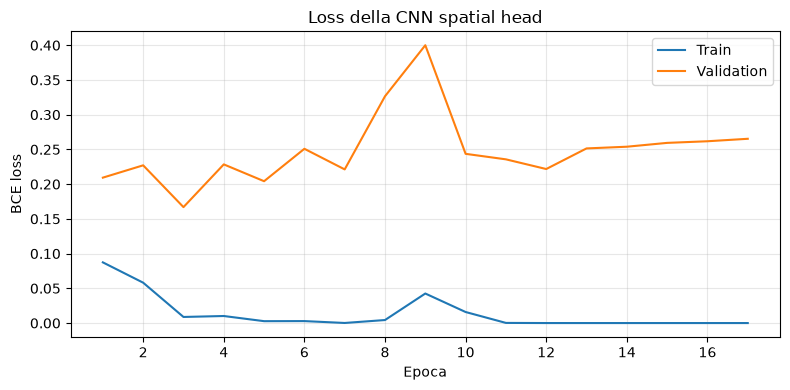

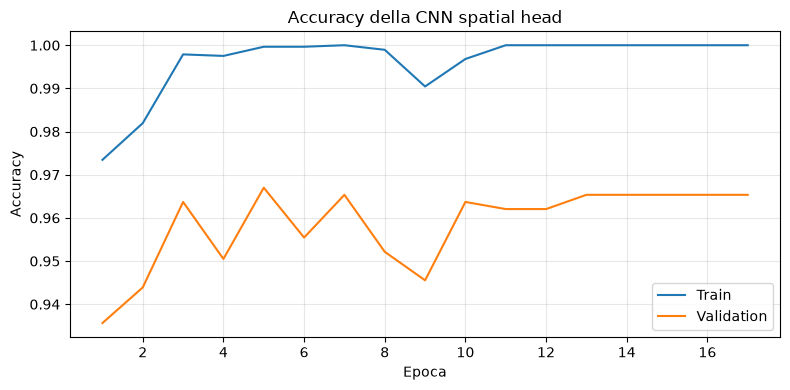

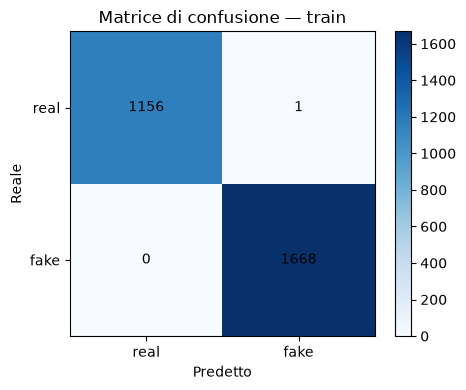

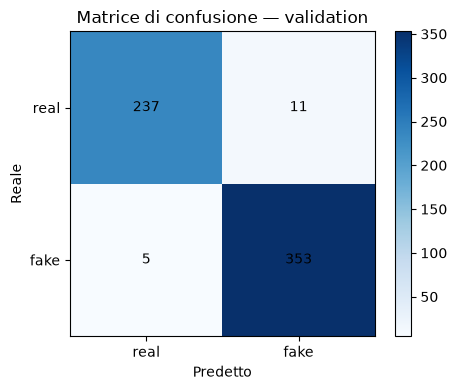

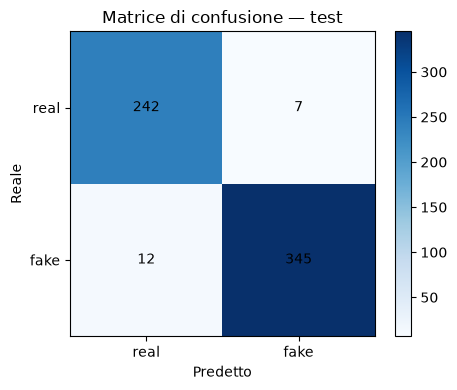

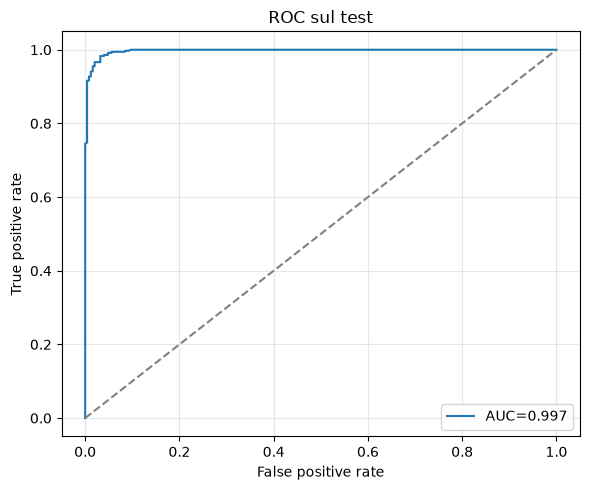

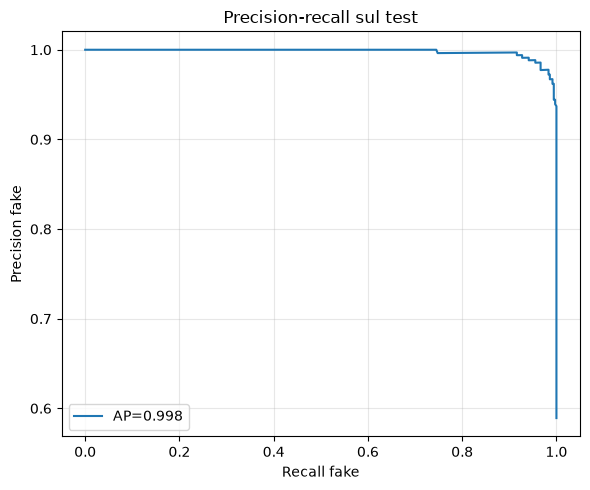

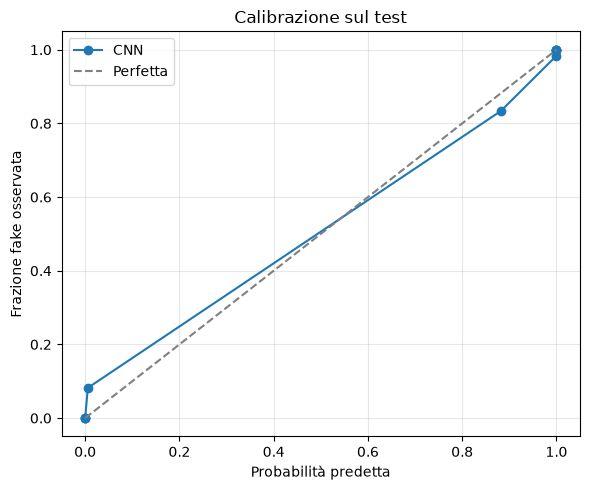

In [9]:
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

plt.figure(figsize=(8, 4))
plt.plot(history_df["step"], history_df["train_loss"], label="Train")
plt.plot(history_df["step"], history_df["val_loss"], label="Validation")
plt.title("Loss della CNN spatial head"); plt.xlabel("Epoca"); plt.ylabel("BCE loss"); plt.grid(alpha=0.3); plt.legend()
save_figure("loss_curve.png")

plt.figure(figsize=(8, 4))
plt.plot(history_df["step"], history_df["train_accuracy"], label="Train")
plt.plot(history_df["step"], history_df["val_accuracy"], label="Validation")
plt.title("Accuracy della CNN spatial head"); plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(alpha=0.3); plt.legend()
save_figure("accuracy_curve.png")

for split_name in ("train", "validation", "test"):
    data = predictions_df.loc[predictions_df["split"] == split_name]
    matrix = confusion_matrix(data["y_true"], data["y_pred"], labels=[0, 1])
    plt.figure(figsize=(5, 4)); plt.imshow(matrix, cmap="Blues")
    plt.title(f"Matrice di confusione — {split_name}"); plt.xticks([0, 1], ["real", "fake"]); plt.yticks([0, 1], ["real", "fake"])
    plt.xlabel("Predetto"); plt.ylabel("Reale")
    for row in range(2):
        for column in range(2):
            plt.text(column, row, str(matrix[row, column]), ha="center", va="center")
    plt.colorbar()
    save_figure(f"confusion_matrix_{split_name}.png")

test_data = predictions_df.loc[predictions_df["split"] == "test"]
test_y, test_p = test_data["y_true"].to_numpy(), test_data["probability"].to_numpy()
fpr, tpr, _ = roc_curve(test_y, test_p)
plt.figure(figsize=(6, 5)); plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(test_y, test_p):.3f}"); plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC sul test"); plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.grid(alpha=0.3); plt.legend()
save_figure("roc_curve.png")

precision, recall, _ = precision_recall_curve(test_y, test_p)
plt.figure(figsize=(6, 5)); plt.plot(recall, precision, label=f"AP={average_precision_score(test_y, test_p):.3f}")
plt.title("Precision-recall sul test"); plt.xlabel("Recall fake"); plt.ylabel("Precision fake"); plt.grid(alpha=0.3); plt.legend()
save_figure("precision_recall_curve.png")

observed, predicted = calibration_curve(test_y, test_p, n_bins=10, strategy="quantile")
plt.figure(figsize=(6, 5)); plt.plot(predicted, observed, marker="o", label="CNN"); plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfetta")
plt.title("Calibrazione sul test"); plt.xlabel("Probabilità predetta"); plt.ylabel("Frazione fake osservata"); plt.grid(alpha=0.3); plt.legend()
save_figure("calibration_curve.png")

## 10. Esportazione e verifica di ricarica

Questa cella salva configurazione, checkpoint migliore e modello TorchScript. Ricarica i due modelli e confronta i logit su un batch validation, così da verificare che l'artefatto sia utilizzabile in locale, Colab e dall'ensemble.

In [10]:
model_config = {
    "model_name": MODEL_NAME, "run_id": RUN_ID, "class_mapping": CLASS_MAPPING, "positive_class": POSITIVE_CLASS,
    "input_shape": [1280, 16, 16], "architecture": {"stem": "Conv1x1 1280->128", "residual_depthwise_blocks": 3, "normalization": "GroupNorm", "channel_attention": True, "pooling": "global_average_and_max", "dropout": DROPOUT},
    "normalization": {"path": str(normalization_path.relative_to(PROJECT_ROOT)), "epsilon": EPSILON, "statistics_split_hash": str(normalization["split_hash"])},
    "split_hash": SPLIT_HASH, "threshold": threshold,
    "training": {"seed": SEED, "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS, "best_epoch": best_epoch, "patience": PATIENCE, "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "gradient_clip_norm": GRADIENT_CLIP_NORM, "amp_enabled": AMP_ENABLED, "training_time_seconds": training_time_seconds},
    "versions": VERSIONS,
}
with (RUN_DIR / "model_config.json").open("w", encoding="utf-8") as handle:
    json.dump(model_config, handle, ensure_ascii=False, indent=2)

cpu_model = CNNSpatialHead().cpu()
cpu_model.load_state_dict(torch.load(RUN_DIR / "best_state_dict.pt", map_location="cpu", weights_only=False)["model_state_dict"])
cpu_model.eval()
scripted_path = RUN_DIR / "best_model_scripted.pt"
torch.jit.save(torch.jit.script(cpu_model), scripted_path)

state_model = CNNSpatialHead().to(DEVICE)
state_model.load_state_dict(torch.load(RUN_DIR / "best_state_dict.pt", map_location=DEVICE, weights_only=False)["model_state_dict"])
state_model.eval()
scripted_model = torch.jit.load(scripted_path, map_location=DEVICE).eval()
verification_values, _ = next(iter(validation_loader))
verification_values = verification_values[:4].to(DEVICE)
with torch.no_grad():
    state_logits = state_model(verification_values).float().cpu().numpy()
    scripted_logits = scripted_model(verification_values).float().cpu().numpy()
if not np.allclose(state_logits, scripted_logits, rtol=1e-4, atol=1e-5):
    raise RuntimeError("TorchScript non riproduce i logit del checkpoint")
print("Verifica di ricarica superata:", RUN_DIR)

c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\jit\_serialization.py:89: FutureWarning: `torch.jit.save` is deprecated. Please switch to `torch.export`.
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\jit\_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Verifica di ricarica superata: C:\Users\leona\venv_aml\results\cnn_spatial_head\seed42_20260917T082650Z


## Output e artefatti prodotti

Ogni esecuzione crea results/cnn_spatial_head/ seguito dal run_id con:

- best_state_dict.pt: pesi del checkpoint selezionato sul validation;
- best_model_scripted.pt: modello TorchScript portabile per inferenza ed ensemble;
- model_config.json: architettura, soglia, normalizzazione, split hash, seed e versioni;
- history.csv: loss, accuracy, balanced accuracy validation e learning rate per epoca;
- metrics.csv: metriche comuni per train, validation e test;
- predictions.csv: sample_id, provenienza, split, label, logit, probabilità e predizione;
- figures: loss, accuracy, matrici di confusione, ROC, precision-recall e calibrazione.

Il notebook non modifica mai features_0.npy o features_1.npy. Le statistiche di normalizzazione sono soltanto lette dal dataset persistente; checkpoint, soglia e iperparametri sono scelti senza usare il test.